In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from llava_utils import load_model, eval_preloaded_model, eval_model, get_conv_mode, pretty_print_results, run_inference, load_image_tensors

In [3]:
# model_path = "liuhaotian/llava-v1.5-7b"
# model_path = "liuhaotian/llava-v1.6-vicuna-7b"
# model_path = 'liuhaotian/llava-v1.6-vicuna-13b'
# model_path = 'liuhaotian/llava-v1.6-mistral-7b'
model_path = "liuhaotian/llava-v1.6-34b"

tokenizer, model, image_processor, context_len = load_model(model_path)
conv_mode = get_conv_mode(model_path)

/home/gazran/miniforge3/envs/sse/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
/home/gazran/miniforge3/envs/sse/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/gazran/miniforge3/envs/sse/lib/python3.10/site-packages/torch/nn/modules/module.py:2025: UserWarning: for vision_mode

Loading checkpoint shards:   0%|          | 0/15 [00:00<?, ?it/s]

In [4]:
from PIL import Image, ImageDraw, ImageFont

def display_res(query, output, image_file, save_path=None):
    img = Image.open(image_file)
    imd = ImageDraw.Draw(img)
    fnt = ImageFont.truetype("LiberationMono-Regular.ttf", 30)
    imd.text((28, 36), f'{query}: {output}', font=fnt, fill=(255, 0, 255))
    if save_path is None:
        img.show()
    else:
        img.save(save_path)

In [7]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")

queries = [
    'Is the robot gripping the white milk carton?',
    'Is the white milk carton on the table?',
    'Is the white milk carton in the dark wood container?',
    'Is the robot gripping the red cereal box?',
    'Is the red cereal box on the table?',
    'Is the red cereal box in the dark wood container?',
    'Is the robot gripping the green bottle?',
    'Is the green bottle on the table?',
    'Is the green bottle in the dark wood container?',
    'Is the robot gripping the red can of soda?',
    'Is the red can of soda on the table?',
    'Is the red can of soda in the dark wood container?',
]

image_files = [
    'examples/groceries_world/start.png',
    'examples/groceries_world/holding_milk.png',
    'examples/groceries_world/milk_in_container.png',
    'examples/groceries_world/holding_cereal.png',
    'examples/groceries_world/cereal_in_container.png',
]

In [17]:
tokenizer.encode("Yes")

[13489]

In [22]:
vocab["YES"]

52096

In [18]:
vocab = tokenizer.get_vocab()

In [ ]:
vocab

In [24]:
prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_files[0], queries[0], conv_mode, system, system_override=True,
                                      get_probs=True)

In [31]:
probs = output[-1]

In [44]:
yes_tokens = tokenizer.encode(['yes', 'Yes', 'YES'])
no_tokens = tokenizer.encode(['no', 'No', 'NO'])

In [37]:
tokenizer.encode('YES')

[52096]

In [49]:
[k for k in vocab.keys() if 'yes' in k.lower() == 'yes']

['yes', 'Yes', 'YES']

In [52]:
yes_probs = probs[yes_tokens].sum()
no_probs = probs[no_tokens].sum()

In [54]:
norm_yes_probs = yes_probs / (yes_probs + no_probs)
norm_no_probs = no_probs / (yes_probs + no_probs)

In [57]:
norm_yes_probs > norm_no_probs

tensor(False)

In [ ]:
from itertools import product

for (i, query), (j, image_file) in product(enumerate(queries), enumerate(image_files)):
    prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
    display_res(query, output + str(tokenizer.encode(output)), image_file)#, save_path=f'quick-n-dirty demo/q{i}_I{j}.png')

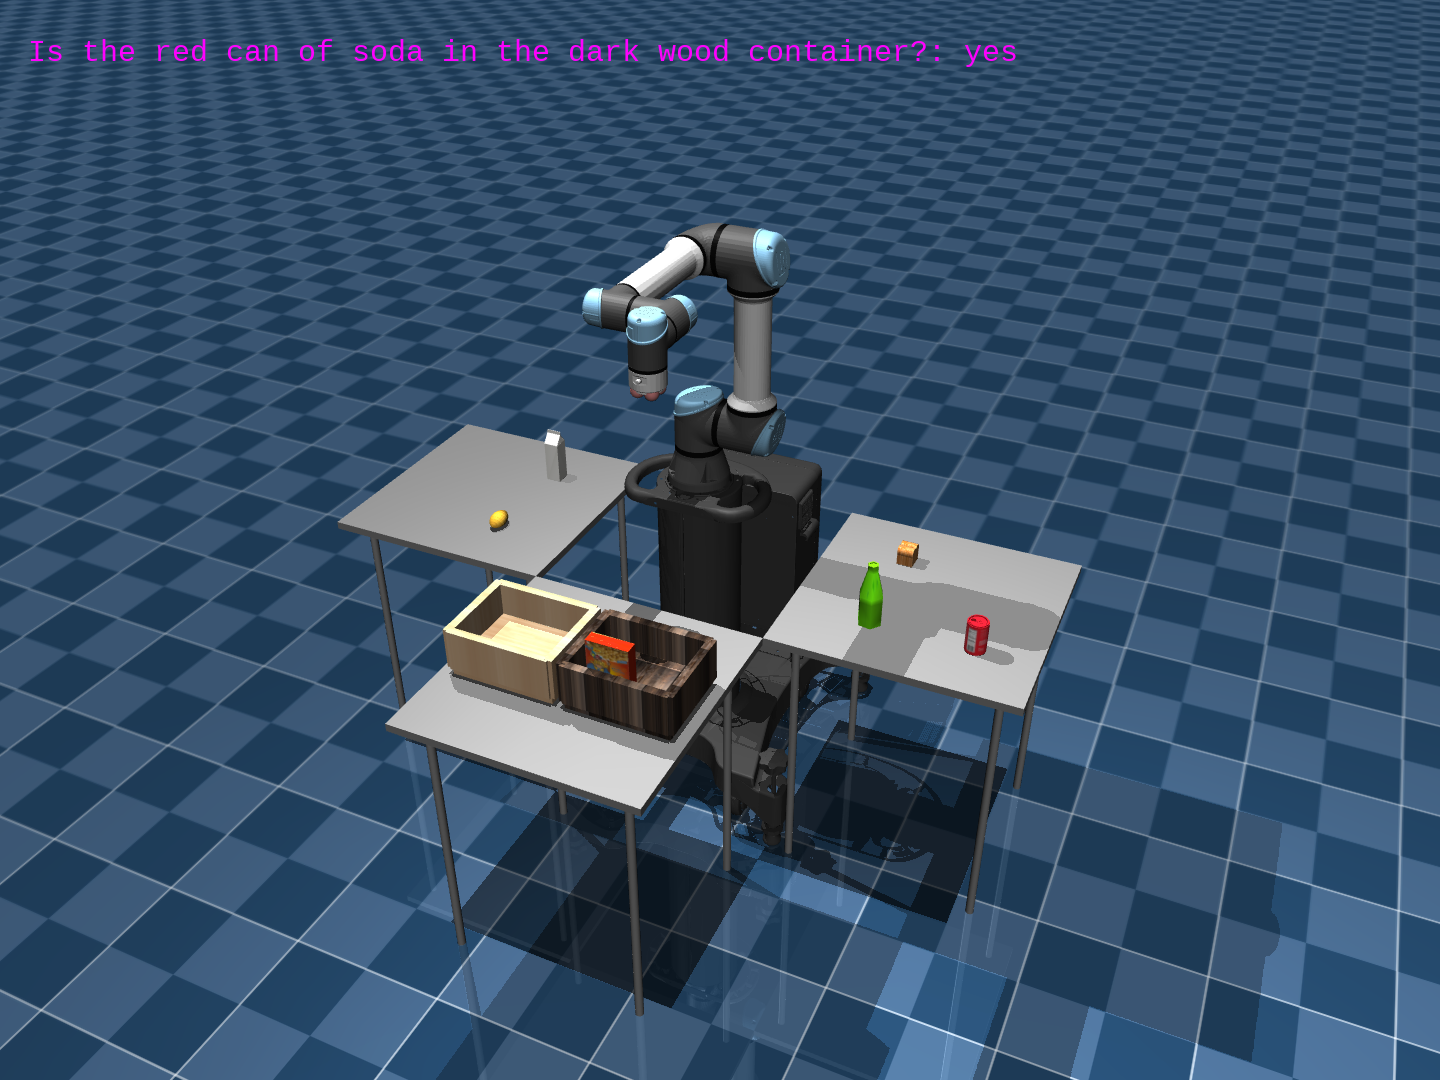

In [58]:
from itertools import product

for (i, query), (j, image_file) in product(enumerate(queries), enumerate(image_files)):
    prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True,
                                         get_probs=True)
    probs = output[-1]
    yes_probs = probs[yes_tokens].sum()
    no_probs = probs[no_tokens].sum()
    display_res(query, 'yes' if yes_probs > no_probs else 'no', image_file)#, save_path=f'quick-n-dirty demo/q{i}_I{j}.png')

In [ ]:

query = "Is the robot holding the milk carton?"
image_file = "start.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
display_res(query, output, image_file)

In [ ]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")
query = "Is the robot holding the carton of milk?"
image_file = "holding_milk.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")
query = "Is the robot holding the red cereal box?"
image_file = "holding_cereal.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")
query = "Is the robot holding the carton of milk?"
image_file = "milk_in_container.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")
query = "Is the red cereal box in the dark wood container?"
image_file = "cereal_in_container.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human is asking an artificial intelligence assistant yes or no questions. "
          "The assistant answers with one of three responses: YES, NO, or UNDECIDED. "
          "The assistant's response should not include any additional text.")
query = "Is the milk carton in the dark wood container?"
image_file = "milk_in_container.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human wants to verify facts about objects in an image using an artificial intelligence assistant. "
          "When the assistant is asked a yes-or-no question, it thinks through its solution step by step and responds honestly to the user whether the statement in the question is true, false, or undecidable with the given image. "
          "The assistant's response is a detailed breakdown of the problem, the conclusion, an explanation for that conclusion, "
          "and a final answer formated as \"Final answer: <yes|no|undecided>\" statement.")
query = "Is the robot holding the carton of milk?"
image_file = "start.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
print(f'{query}: {output}')
Image.open(image_file)

In [ ]:
system = ("A curious human wants to verify facts about objects in an image using an artificial intelligence assistant. "
          "When the assistant is asked a yes-or-no question, it thinks through its solution step by step and responds honestly to the user whether the statement in the question is true, false, or undecidable with the given image. "
          "The assistant's response is a detailed breakdown of the problem, the conclusion, an explanation for that conclusion.")
          # "and a final answer formated as \"Final answer: <yes|no|undecided>\" statement.")
query = "Is the milk carton near the robot end-effector?"
image_file = "holding_milk.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
pretty_print_results(prompt, output)

In [ ]:
system = ("A curious human wants to verify facts about objects in an image using an artificial intelligence assistant. "
          "When the assistant is asked a yes-or-no question, it thinks through its solution step by step and responds honestly to the user whether the statement in the question is true, false, or undecidable with the given image. "
          "The assistant's response is a detailed breakdown of the problem, the conclusion, an explanation for that conclusion.")
query = "Is the robot holding the carton of milk?"
image_file = "milk_in_container.png"

prompt, output = eval_preloaded_model(tokenizer, model, image_processor, image_file, query, conv_mode, system, system_override=True)
pretty_print_results(prompt, output)